In [1]:
import numpy as np
import math

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker, cm

import matplotlib.gridspec as gridspec

import scipy
from scipy import interpolate
from scipy.sparse import diags
import scipy.sparse as sp

In [3]:
# constant variables
PI = math.pi

dilution = "FastDilution" # "FastDilution"

# define diffusion coefficient
Diff_h = 25.0 # [m2 s-1]
Diff_z = 0.6 # [m2 s-1]

# define a fixed wind field
U_shear = 0.07 # [s-1]


# # slow dilution
# # define diffusion coefficient
# Diff_h = 10.0 # [m2 s-1]
# Diff_z = 0.15 # [m2 s-1]

# # define a fixed wind field
# U_shear = 0.002 # [s-1]

In [4]:
# *** Attention: this gaussian analytical results does NOT requires Dv=Dh
# Chris J. Walcek-A Gaussian dispersionplume model explicitly account

cc = 1.0 # [kg] or [kg/s]
def CrossSection_Concnt_2D(time, Diff_h, Diff_z, U_shear):
# def CrossSection_Concnt_2D(time, Diff_h, Diff_z, U_shear, Nh, Nz, X, Y, cc):

    # time = ? [s]
    # Diff_h, Diff_z are horizontal and vertical diffusivity
    # U_shear is vertical wind shear
    # X, Y form a 2D grid/domain with grid number [Nz, Nh]
    # cc: initial injection mass

    # gaussian analytical result
    Sigma_h = math.sqrt( 2.0*Diff_h*time ) # [m]
    Sigma_z = math.sqrt( 2.0*Diff_z*time ) # [m]

    s = U_shear*time* Sigma_z/Sigma_h

#     C_gau = np.zeros([Nz,Nh])

#     for iz in range(Nz):
#         for ih in range(Nh):
#             C_gau[iz,ih] = cc/( 2*PI*Sigma_h*Sigma_z*math.sqrt(1+s**2/12) )* \
#                             math.exp(-X[iz,ih]**2/(2*Sigma_h**2*(1+s**2/12)) \
#                                      -Y[iz,ih]**2*(1+s**2 /3)/(2*Sigma_z**2*(1+s**2/12)) \
#                                      +X[iz,ih]*Y[iz,ih]/(2*Sigma_h*Sigma_z)*(s/(1+s**2/12))
#                                      )
#     Rh = Sigma_h + 2/3*math.sqrt(2.0*Diff_z)*U_shear*(time**3/2)
#     Rz = Sigma_z

    A_true = PI*Sigma_h*Sigma_z*math.sqrt(1+s**2/12)
    A_false = PI*Sigma_h*Sigma_z
    
    return Sigma_h, Sigma_z, s, A_true, A_false

In [5]:
time = 10 # [s]
Sigma_h0, Sigma_z0, s0, A, A2 = CrossSection_Concnt_2D(time, Diff_h, Diff_z, U_shear)

print(Sigma_h0, Sigma_z0, s0, A, A2)

22.360679774997898 3.4641016151377544 0.10844353369380767 243.4659312520225 243.3467205584167


In [6]:
Total_day = 40
Total_hour = Total_day*24
Total_minute = Total_hour*60

A_list = [0]
Hour_list = [0]

for it_min in range(Total_minute):
    t_second = (it_min+1)*60
#     print(t_second)
    
    Sigma_h0, Sigma_z0, s0, A, A2 = CrossSection_Concnt_2D(t_second, Diff_h, Diff_z, U_shear)

    A_list.append(A)
    Hour_list.append(it_min+1)

Text(0, 0.5, 'Plume Cross Area [m2]')

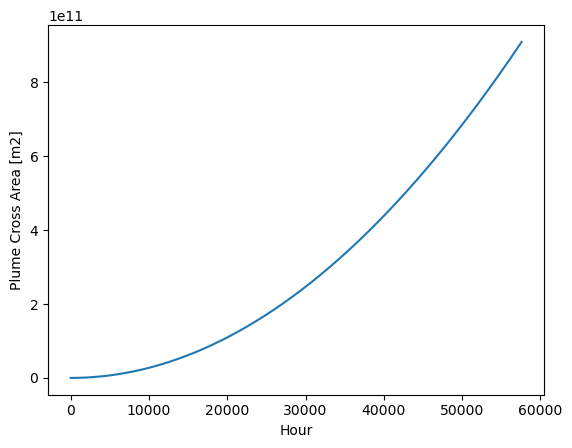

In [8]:
plt.plot(Hour_list, A_list);
plt.xlabel("Hour")
plt.ylabel("Plume Cross Area [m2]")

In [9]:
import pandas as pd

d = {'Hour': Hour_list, 'Area [m2]': A_list}
df = pd.DataFrame(data=d)
df.to_csv(f'Time_series_of_CrossSection_Area_{dilution}.csv', index=False) 

/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
